In [10]:
import sys
from pathlib import Path

# Allow imports from project root
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.config import CONFIG, PROJECT_ROOT

# Plotting config
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "aaa_spread": "#1b9e77",
    "aa_spread":  "#7570b3",
    "bbb_spread": "#d95f02",
    "hy_spread":  "#e7298a",
    "vix":        "#666666",
}

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

In [11]:
df = pd.read_csv(
    PROJECT_ROOT / "data/processed/master_with_regimes.csv",
    index_col=0, parse_dates=True,
)
trans_matrix = pd.read_csv(PROJECT_ROOT / "results/transition_matrix.csv", index_col=0)
regime_stats = pd.read_csv(PROJECT_ROOT / "results/regime_stats.csv")

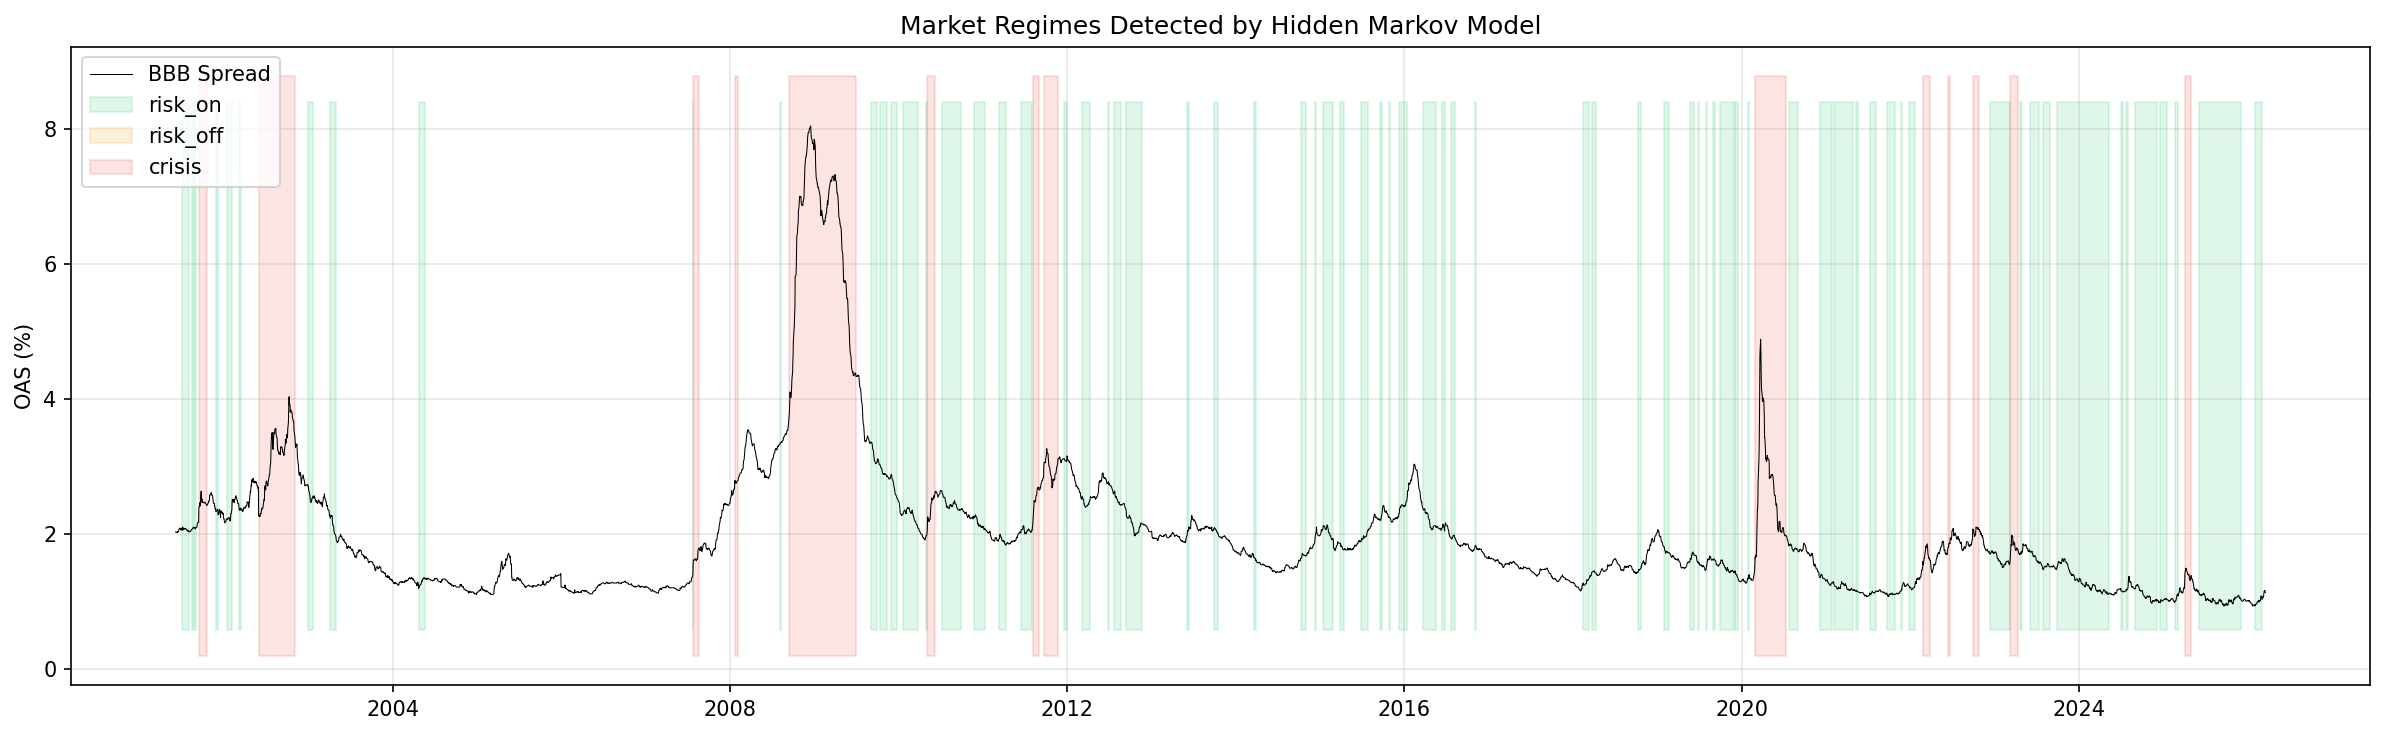

In [12]:
regime_colors = {"risk_on": "#2ecc71", "risk_off": "#f39c12", "crisis": "#e74c3c"}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["bbb_spread"], color="black", linewidth=0.5, label="BBB Spread")

# Color background by regime
for regime, color in regime_colors.items():
    mask = df["regime"] == regime
    ax.fill_between(df.index, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=mask, alpha=0.15, color=color, label=regime)

ax.set_ylabel("OAS (%)")
ax.set_title("Market Regimes Detected by Hidden Markov Model")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "regime_timeline.png", bbox_inches="tight")
plt.show()

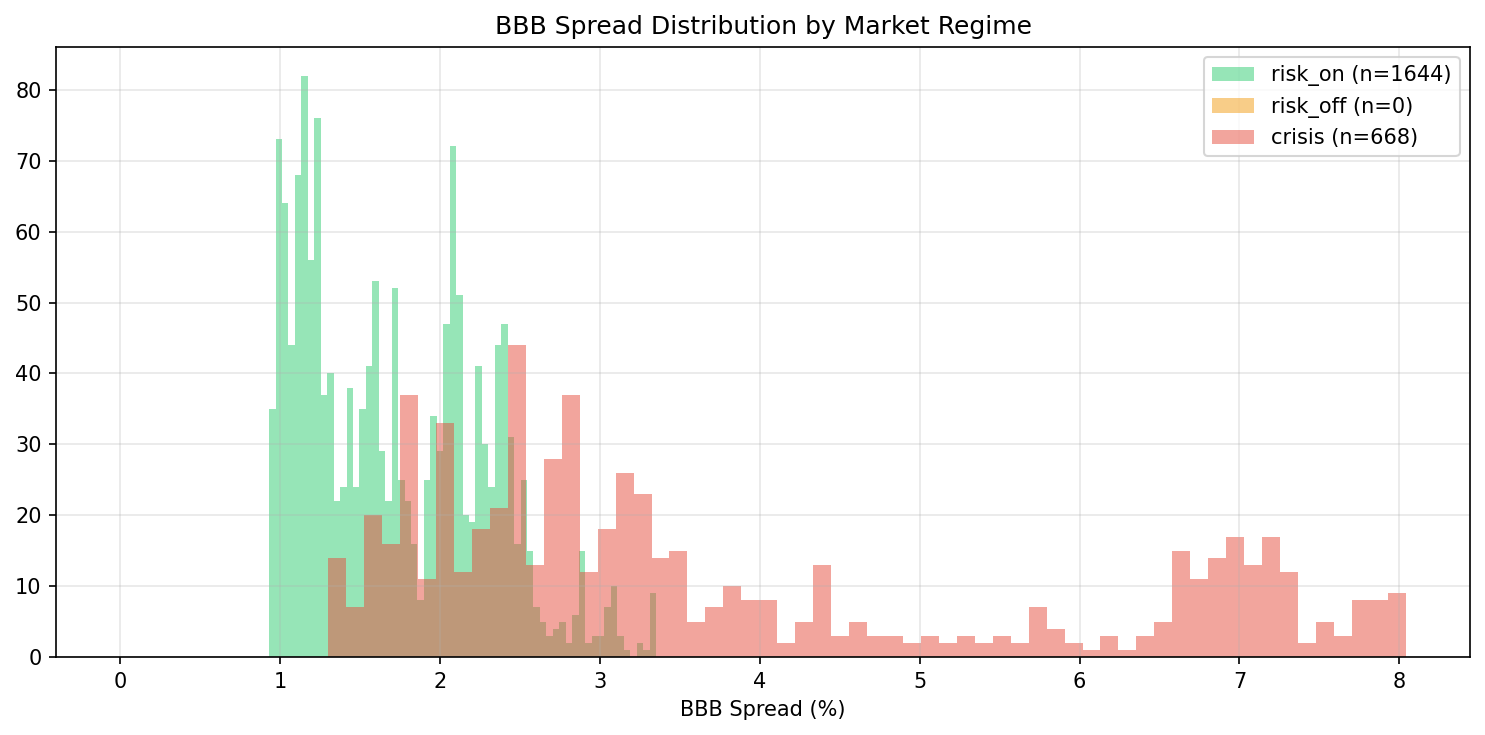

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for regime, color in regime_colors.items():
    data = df.loc[df["regime"] == regime, "bbb_spread"]
    ax.hist(data, bins=60, alpha=0.5, color=color, label=f"{regime} (n={len(data)})")

ax.set_xlabel("BBB Spread (%)")
ax.set_title("BBB Spread Distribution by Market Regime")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "regime_distributions.png", bbox_inches="tight")
plt.show()

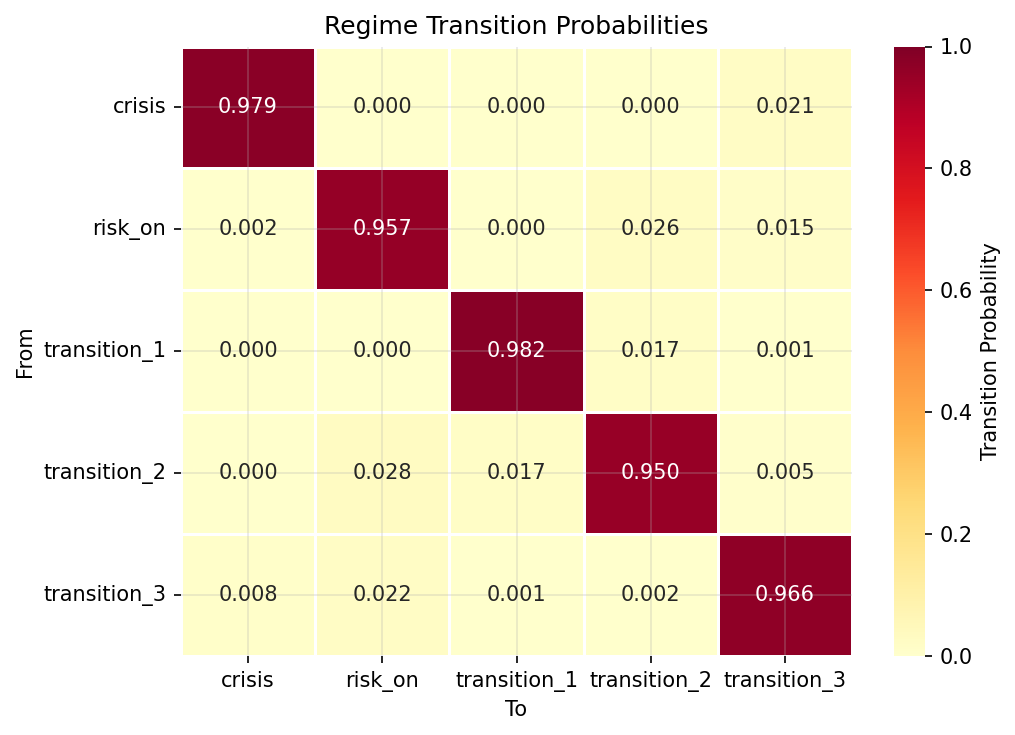

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    trans_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={"label": "Transition Probability"},
)
ax.set_title("Regime Transition Probabilities")
ax.set_ylabel("From")
ax.set_xlabel("To")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "transition_matrix.png", bbox_inches="tight")
plt.show()

         start         end  duration_days  peak_spread  half_life_days
0   2001-09-14  2001-10-19             35         2.63             1.0
1   2002-05-31  2002-11-05            158         4.03             NaN
2   2007-07-26  2007-08-22             27         1.79             NaN
3   2008-01-22  2008-02-06             15         2.80             NaN
4   2008-09-15  2009-06-30            288         8.04           142.0
5   2010-05-06  2010-06-09             34         2.62             NaN
6   2011-08-08  2011-09-02             25         2.69             NaN
7   2011-09-22  2011-11-23             62         3.26             8.0
8   2020-02-27  2020-07-13            137         4.88            22.0
9   2022-02-25  2022-03-25             28         1.85             3.0
10  2022-09-28  2022-10-25             27         2.10             6.0
11  2023-03-10  2023-04-11             32         1.98             7.0
12  2025-04-03  2025-05-01             28         1.49             8.0


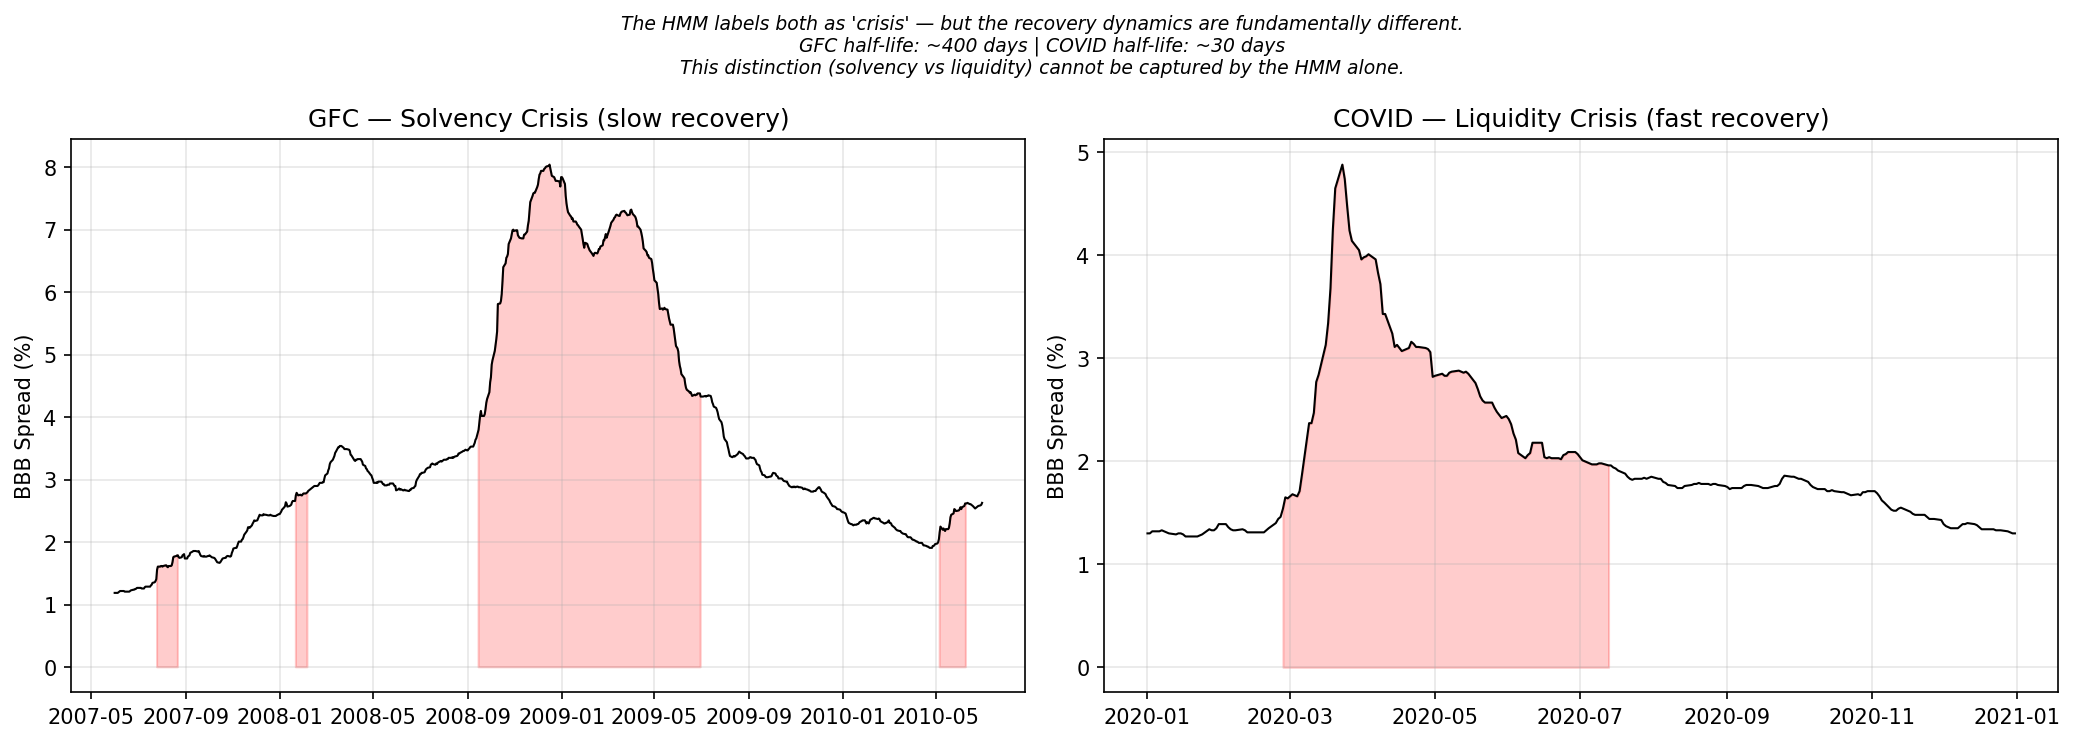

In [15]:
# Identify crisis episodes
crisis_mask = df["regime"] == "crisis"
crisis_blocks = (crisis_mask != crisis_mask.shift()).cumsum()
crisis_episodes = []

for block_id in df.loc[crisis_mask, "regime"].groupby(crisis_blocks[crisis_mask]).groups:
    episode = df.loc[crisis_blocks == block_id]
    if len(episode) > 10:  # skip very short episodes
        start = episode.index[0]
        end = episode.index[-1]
        peak_spread = episode["bbb_spread"].max()
        start_spread = episode["bbb_spread"].iloc[0]
        
        # Half-life: how many days to reach halfway back from peak
        half_level = (peak_spread + start_spread) / 2
        post_peak = episode.loc[episode["bbb_spread"].idxmax():]
        half_life_mask = post_peak["bbb_spread"] < half_level
        half_life = (half_life_mask.idxmax() - episode["bbb_spread"].idxmax()).days if half_life_mask.any() else None
        
        crisis_episodes.append({
            "start": start.date(),
            "end": end.date(),
            "duration_days": (end - start).days,
            "peak_spread": peak_spread,
            "half_life_days": half_life,
        })

episodes_df = pd.DataFrame(crisis_episodes)
print(episodes_df.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GFC zoom
gfc = df.loc["2007-06":"2010-06"]
axes[0].plot(gfc.index, gfc["bbb_spread"], color="black", linewidth=1)
axes[0].fill_between(gfc.index, 0, gfc["bbb_spread"],
                     where=gfc["regime"]=="crisis", alpha=0.2, color="red")
axes[0].set_title("GFC — Solvency Crisis (slow recovery)")
axes[0].set_ylabel("BBB Spread (%)")

# COVID zoom
covid = df.loc["2020-01":"2020-12"]
axes[1].plot(covid.index, covid["bbb_spread"], color="black", linewidth=1)
axes[1].fill_between(covid.index, 0, covid["bbb_spread"],
                     where=covid["regime"]=="crisis", alpha=0.2, color="red")
axes[1].set_title("COVID — Liquidity Crisis (fast recovery)")
axes[1].set_ylabel("BBB Spread (%)")

fig.suptitle(
    "The HMM labels both as 'crisis' — but the recovery dynamics are fundamentally different.\n"
    "GFC half-life: ~400 days | COVID half-life: ~30 days\n"
    "This distinction (solvency vs liquidity) cannot be captured by the HMM alone.",
    fontsize=9, style="italic",
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "crisis_halflife_comparison.png", bbox_inches="tight")
plt.show()